# 8. The backtest: do the models beat the rule of thumb?

**What this notebook answers:** we have several ways to price "will it touch $K within T?". Which
one is best, by how much, is that difference real or luck, and how far can we trust the answer?

**Scope up front (please read):**

* The contracts here are **synthetic**: for each moment in history we imagine a venue listing 1-, 7- and 30-day touch contracts on a grid of strikes, then use the Kraken tick data to see what really happened. There are no *market prices* in this backtest, so it measures **forecast quality, not trading profit**. Notebook 9 compares against real Polymarket prices.
* Results are for Bitcoin 2019-2025 (Ethereum 2020-2025 and Solana 2024-2025 as robustness checks).
* Every number is **out-of-sample** and every confidence interval respects that overlapping contracts are not independent.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, polars as pl, matplotlib.pyplot as plt
import _style as st
from pmq.crypto import backtest as bt
from pmq.eval import scoring

st.setup()
data = {a: pl.read_parquet(f"../outputs/backtest_{a}.parquet") for a in ("XBT", "ETH", "SOL")}
btc = data["XBT"]
DESC = {
    "naive_2x": "Rule of thumb: twice P(finish beyond), trailing 30-day volatility",
    "gbm_trailing30": "Exact touch formula, trailing 30-day volatility",
    "gbm_rv7": "Exact touch formula, last 7 days of realised variance",
    "gbm_ewma": "Exact touch formula, EWMA volatility (5-day half-life)",
    "gbm_har": "Exact touch formula, log-HAR mean-variance forecast",
    "bayes_disc": "Bayesian discounted volatility belief (10-day memory), averaged",
    "har_mix": "log-HAR forecast averaged over its own forecast error",
    "har_mix_recal": "har_mix, then recalibrated on the previous years",
    "base_rate": "Historical hit frequency for that strike bucket (benchmark, not a live pricer)",
}

## 8.1 How the experiment works

1. **Contracts.** Every 6 hours, for horizons of 1, 7 and 30 days, list touch contracts at strikes above *and* below the price. Strikes sit at $z \in \{0.5,1,\dots,3\}$ **trailing-30-day volatilities** away. No model under test chooses the strikes.
2. **Labels.** A contract is "hit" if any 1-minute high (or low) inside the window reaches the strike, the way a venue would settle it.
3. **Forecasts.** Each model prices every contract using only information from before the contract opened. `tests/test_no_lookahead.py` rewrites the future and checks the forecasts do not move.
4. **Walk-forward, purged.** Anything fitted (HAR coefficients, forecast-error spread, recalibration, base rates) is fitted **only on contracts whose outcome was already known on 1 January of the test year**, then used for that whole year.
5. **Scores.** Log loss and Brier (lower is better), Brier skill against the naive rule, and calibration slope (1 is perfect; below 1 means over-confident).
6. **Uncertainty.** Contracts opened hours apart are almost the same bet, so confidence intervals **resample whole weeks**.

In [2]:
summary = pd.DataFrame({
    a: {"contracts": d.height, "test weeks": d["week"].n_unique(), "contracts per week": d.height / d["week"].n_unique(),
        "share hit": d["label"].mean(), "test years": f'{d["year"].min()}-{d["year"].max()}'}
    for a, d in data.items()}).T
summary

,contracts,test weeks,contracts per week,share hit,test years
XBT,363888,362,1005.21547,0.195027,2019-2025
ETH,311328,310,1004.283871,0.203339,2020-2025
SOL,100944,101,999.445545,0.185647,2024-2025


## 8.2 Bitcoin results

In [3]:
tbl = bt.score_table(btc).to_pandas().set_index("model").sort_values("log_loss")
tbl["description"] = tbl.index.map(DESC)
tbl[["log_loss", "brier", "brier_skill_vs_naive", "calibration_slope", "description"]].round(4)

,log_loss,brier,brier_skill_vs_naive,calibration_slope,description
model,,,,,
har_mix,0.3850,0.1216,0.0327,0.9061,log-HAR forecast averaged over its own forecas...
har_mix_recal,0.3851,0.1215,0.0334,1.0568,"har_mix, then recalibrated on the previous years"
base_rate,0.3934,0.1236,0.0172,1.0099,Historical hit frequency for that strike bucke...
gbm_har,0.3955,0.1248,0.0072,0.7875,"Exact touch formula, log-HAR mean-variance for..."
gbm_trailing30,0.4131,0.1250,0.0061,0.6446,"Exact touch formula, trailing 30-day volatility"
naive_2x,0.4146,0.1257,0.0000,0.6379,"Rule of thumb: twice P(finish beyond), trailin..."
bayes_disc,0.4154,0.1248,0.0078,0.6306,Bayesian discounted volatility belief (10-day ...
gbm_ewma,0.4239,0.1253,0.0038,0.5908,"Exact touch formula, EWMA volatility (5-day ha..."
gbm_rv7,0.4425,0.1277,-0.0158,0.5169,"Exact touch formula, last 7 days of realised v..."


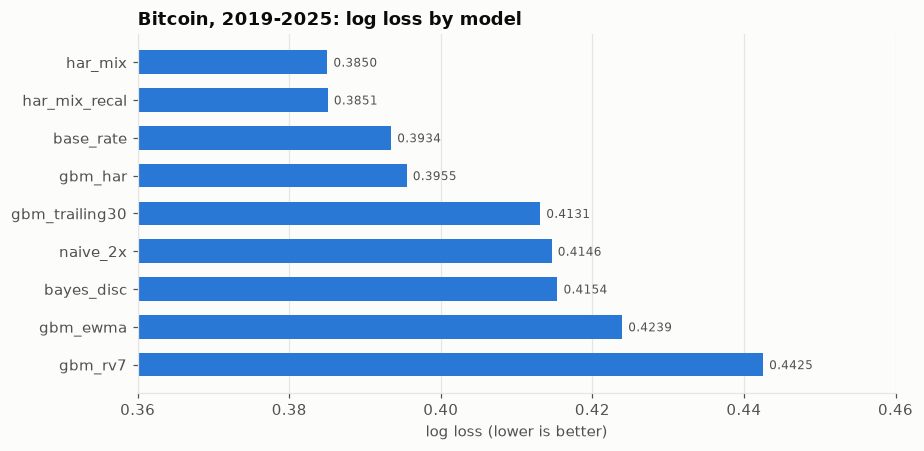

In [4]:
order = tbl.index[::-1]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.barh(order, tbl.loc[order, "log_loss"], color=st.BLUE, height=0.62)
for b in bars:
    ax.annotate(f"{b.get_width():.4f}", (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(4, -3), textcoords="offset points", fontsize=8, color=st.INK_SOFT)
ax.set_xlim(0.36, 0.46); ax.set_xlabel("log loss (lower is better)"); ax.set_title("Bitcoin, 2019-2025: log loss by model")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### Where the improvement comes from (an ablation chain)

Reading the table top to bottom is a story in three steps:

1. **Exact formula versus the rule of thumb**: `gbm_trailing30` vs `naive_2x` is a tiny gain (0.0015 in log loss). The "2 x digital" shortcut is nearly as good as the exact formula when both use the same volatility.
2. **A better volatility forecast** (`gbm_har`): a real step. The volatility input matters far more than the formula.
3. **Honest uncertainty about that forecast** (`har_mix`): another clear step, worth about half as much again as the forecast improvement. Fat tails caused by volatility uncertainty are not a footnote.

Meanwhile `bayes_disc`, the Bayesian belief about the *past* volatility, is indistinguishable from the plug-in: as notebook 6 predicted, uncertainty about the past is too small to matter.

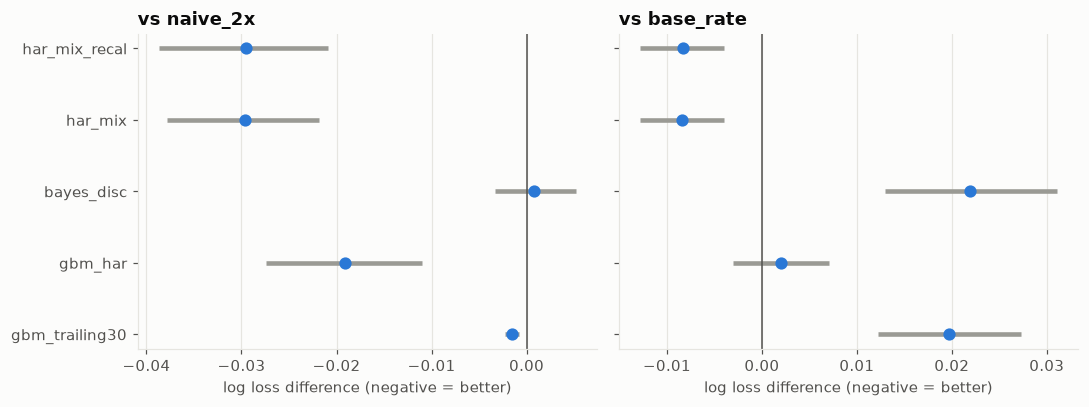

log_loss_diff  ci_low  ci_high
vs        model                                         
naive_2x  gbm_trailing30        -0.0015 -0.0023  -0.0008
          gbm_rv7                0.0279  0.0175   0.0391
          gbm_ewma               0.0093  0.0032   0.0158
          gbm_har               -0.0191 -0.0275  -0.0111
          bayes_disc             0.0008 -0.0034   0.0052
          har_mix               -0.0296 -0.0378  -0.0218
          har_mix_recal         -0.0295 -0.0387  -0.0209
          base_rate             -0.0212 -0.0290  -0.0135
base_rate naive_2x               0.0212  0.0135   0.0290
          gbm_trailing30         0.0197  0.0122   0.0273
          gbm_rv7                0.0491  0.0344   0.0649
          gbm_ewma               0.0305  0.0194   0.0418
          gbm_har                0.0021 -0.0030   0.0071
          bayes_disc             0.0219  0.0129   0.0311
          har_mix               -0.0084 -0.0128  -0.0039
          har_mix_recal         -0.0084 -0.0129  -0.0040

In [5]:
rows = []
for baseline in ("naive_2x", "base_rate"):
    rows.append(bt.loss_difference_table(btc, baseline).to_pandas())
diff = pd.concat(rows)
show = diff[diff["model"].isin(["gbm_trailing30", "gbm_har", "bayes_disc", "har_mix", "har_mix_recal"])]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, baseline in zip(axes, ("naive_2x", "base_rate")):
    d = show[show["vs"] == baseline].set_index("model").loc[["gbm_trailing30", "gbm_har", "bayes_disc", "har_mix", "har_mix_recal"]]
    y = np.arange(len(d))
    ax.hlines(y, d["ci_low"], d["ci_high"], color=st.GREY, lw=3)
    ax.plot(d["log_loss_diff"], y, "o", color=st.BLUE, ms=7)
    ax.axvline(0, color=st.INK_SOFT, lw=1)
    ax.set_yticks(y, d.index); ax.set_title(f"vs {baseline}"); ax.set_xlabel("log loss difference (negative = better)")
    ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
diff.round(4).set_index(["vs", "model"])

The horizontal bars are 95% intervals from resampling whole weeks. An interval that stays to the left of zero is a difference we can call real.
`har_mix` and its recalibrated twin are clearly better than the naive rule. Against the historical **base rate** (which knows nothing about
volatility but has seen the exact strike buckets, so it is a *strong* benchmark) the gap is smaller (about 0.008) but the interval still excludes zero. The plain HAR plug-in (`gbm_har`) does **not** beat the base rate: the whole edge over it comes from the uncertainty mixing. Recalibration adds nothing, because the mixture is already close to calibrated.

## 8.3 Was it consistent, or did one year carry it?

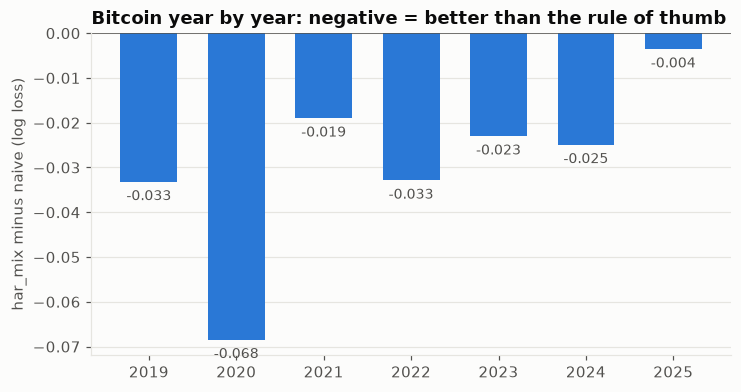

In [6]:
yr = bt.score_table(btc, ["year"]).to_pandas().pivot(index="year", columns="model", values="log_loss")
gap = (yr["har_mix"] - yr["naive_2x"]).sort_index()
fig, ax = plt.subplots()
ax.bar(gap.index.astype(str), gap.values, color=[st.BLUE if v < 0 else st.ORANGE for v in gap.values], width=0.65)
for i, v in enumerate(gap.values):
    ax.annotate(f"{v:+.3f}", (i, v), xytext=(0, 4 if v > 0 else -12), textcoords="offset points", ha="center", fontsize=9, color=st.INK_SOFT)
ax.axhline(0, color=st.INK_SOFT, lw=1); ax.set_ylabel("har_mix minus naive (log loss)"); ax.set_title("Bitcoin year by year: negative = better than the rule of thumb")
ax.grid(axis="x", visible=False)
plt.show()

For Bitcoin the mixture beats the naive rule in **all seven test years**, but very unevenly: −0.069 in 2020 (a violent year the naive trailing window under-reacted to) down to only **−0.004 in 2025**, which is a statistical tie. For Ethereum it wins in five of six years and **loses in 2023** (+0.013). So the average gain (about −0.03) is real but comes mostly from turbulent years; in calm years there is little left to gain. A look at 2025 shows why: the mixture over-stated far-strike hit rates (2.7% predicted at z = 3, against 1.4% that happened) while the naive rule under-stated them (0.3%). The mixture's extra tail is worth having on average and costs a little when the market is unusually quiet.

## 8.4 Calibration: do the stated probabilities mean what they say?

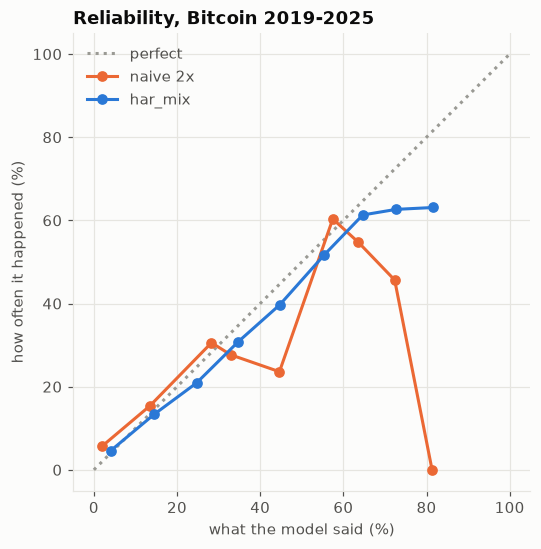

calibration slope (1 = perfect): {'naive_2x': 0.64, 'gbm_har': 0.79, 'har_mix': 0.91, 'har_mix_recal': 1.06}


In [7]:
fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.plot([0, 100], [0, 100], color=st.GREY, ls=":", label="perfect")
for m, colour, label in (("naive_2x", st.ORANGE, "naive 2x"), ("har_mix", st.BLUE, "har_mix")):
    t = pd.DataFrame(scoring.reliability_table(btc[m].to_numpy(), btc["label"].to_numpy(), bins=10))
    ax.plot(t["mean_forecast"] * 100, t["frequency"] * 100, "o-", color=colour, label=label)
ax.set_xlabel("what the model said (%)"); ax.set_ylabel("how often it happened (%)"); ax.set_title("Reliability, Bitcoin 2019-2025"); ax.legend(); ax.set_aspect("equal")
plt.show()
slopes = bt.score_table(btc).to_pandas().set_index("model")["calibration_slope"]
print("calibration slope (1 = perfect):", slopes.loc[["naive_2x", "gbm_har", "har_mix", "har_mix_recal"]].round(2).to_dict())

The naive curve is flatter than the diagonal: it is **over-confident** (calibration slope about 0.64): when it says 50% the event happens
less than half the time, and when it says 5% it happens more often. The mixture hugs the diagonal (slope near 0.9-1.0).
That is the practical meaning of "fat tails": a model that ignores volatility uncertainty is too sure of itself.

## 8.5 How many independent observations do we really have?

There are hundreds of thousands of contracts but only a few hundred *weeks*. Treating each contract as independent makes the evidence look far stronger than it is:

In [8]:
y = btc["label"].to_numpy()
a = scoring.log_loss_each(btc["har_mix"].to_numpy(), y); b = scoring.log_loss_each(btc["naive_2x"].to_numpy(), y)
d = a - b
naive_se = d.std() / np.sqrt(d.size)
mean, lo, hi = scoring.cluster_bootstrap_difference(a, b, btc["week"].to_numpy())
pd.DataFrame({"if every contract were independent": [d.mean() - 1.96 * naive_se, d.mean() + 1.96 * naive_se],
              "resampling whole weeks (honest)": [lo, hi]}, index=["95% low", "95% high"]).T.assign(width=lambda x: x["95% high"] - x["95% low"]).round(4)

,95% low,95% high,width
if every contract were independent,-0.0307,-0.0285,0.0021
resampling whole weeks (honest),-0.0378,-0.0218,0.0160


The honest interval is **about eight times wider**. This is why the project always resamples weeks: with 364,000 contracts but 362 weeks, the true
amount of independent evidence is closer to the weeks. It also warns that any claim built on a *small* number of weeks (as with Solana below) should be held loosely.

## 8.6 Do other coins agree?

In [9]:
rows = []
for a, d in data.items():
    ll = bt.score_table(d).to_pandas().set_index("model")
    diff = bt.loss_difference_table(d, "naive_2x").to_pandas().set_index("model").loc["har_mix"]
    rows.append({"asset": {"XBT": "Bitcoin", "ETH": "Ethereum", "SOL": "Solana"}[a], "test years": f'{d["year"].min()}-{d["year"].max()}', "weeks": d["week"].n_unique(),
                 "naive log loss": ll.loc["naive_2x", "log_loss"], "har_mix log loss": ll.loc["har_mix", "log_loss"],
                 "difference": diff["log_loss_diff"], "95% low": diff["ci_low"], "95% high": diff["ci_high"],
                 "har_mix Brier skill": ll.loc["har_mix", "brier_skill_vs_naive"], "har_mix calibration slope": ll.loc["har_mix", "calibration_slope"]})
pd.DataFrame(rows).set_index("asset").round(4)

,test years,weeks,naive log loss,har_mix log loss,difference,95% low,95% high,har_mix Brier skill,har_mix calibration slope
asset,,,,,,,,,
Bitcoin,2019-2025,362,0.4146,0.3850,-0.0296,-0.0378,-0.0218,0.0327,0.9061
Ethereum,2020-2025,310,0.4245,0.3994,-0.0251,-0.0335,-0.0167,0.0202,0.8376
Solana,2024-2025,101,0.3520,0.3485,-0.0035,-0.0134,0.0054,0.0088,1.0519


**Bitcoin and Ethereum agree**: a clear, out-of-sample improvement, with intervals that exclude zero and Brier skill positive. **Solana is
inconclusive**: only two test years (about 100 weeks), the improvement is small and the interval straddles zero. The correct reading is "no evidence
either way yet", not "it works" or "it fails".

## 8.7 By horizon

In [10]:
h = bt.score_table(btc, ["horizon_d"]).to_pandas()
h = h[h["model"].isin(["naive_2x", "gbm_har", "har_mix", "base_rate"])].pivot(index="horizon_d", columns="model", values="log_loss")
h["har_mix improvement vs naive"] = h["har_mix"] - h["naive_2x"]
h.round(4)

model,base_rate,gbm_har,har_mix,naive_2x,har_mix improvement vs naive
horizon_d,,,,,
1.0,0.3637,0.3679,0.3554,0.3773,-0.0220
7.0,0.3873,0.3915,0.3815,0.4029,-0.0214
30.0,0.4294,0.4271,0.4182,0.4636,-0.0454


The improvement is present at every horizon. Longer horizons have higher losses for everyone (more scope for surprises).

## 8.8 What this does and does not show

**Shows**

* On Bitcoin and Ethereum, pricing touch contracts with a forecast volatility **and its uncertainty** beats a widely used rule of thumb, out-of-sample, with intervals that respect overlapping contracts.
* Most of the gain comes from two places: a better volatility forecast (log-HAR) and averaging over its error. Neither the exact formula nor a Bayesian belief about *past* volatility helps much on its own.
* The gain is not uniform in time: large in turbulent years, close to zero for Bitcoin in 2025, and negative for Ethereum in 2023.

**Does not show**

* **Trading profit.** There are no market prices here. Whether these forecasts beat a *market* is the question of notebook 9, and a market has information (and costs) this test lacks.
* **Real venue strikes.** Strikes here are on a volatility grid; venues list round numbers. Coverage of very far strikes is thin.
* **Solana.** Too little history to say.
* **Anything about 2026.** The tick data ends on 31 December 2025.
* **Drift.** All models assume zero price drift; a trend view would change the answers (notebook 4).
* **Resolution differences.** Labels use Kraken prints; venues settle on their own sources (Binance candles), which differ slightly near the strike.